In [1]:
import os
import pandas as pd

# 1. List everything Kaggle mounted under /kaggle/input so you see the real path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
y = df['charges']
X = df.drop(columns=['charges'])

X = pd.get_dummies(X, columns=['sex','smoker','region'],drop_first=True)


In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)

import numpy as np

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:,.2f}")    
print(f"MAE : {mae:,.2f}")
print(f"R^2 : {r2:.3f}")    

RMSE: 5,796.28
MAE : 4,181.19
R^2 : 0.784


In [7]:
import pandas as pd

# Pair each feature name with its learned coefficient, sorted by size
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

print("Intercept:", round(model.intercept_, 2))
print(coefs.to_string(index=False))

Intercept: -11931.22
         feature  coefficient
      smoker_yes 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
        sex_male   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


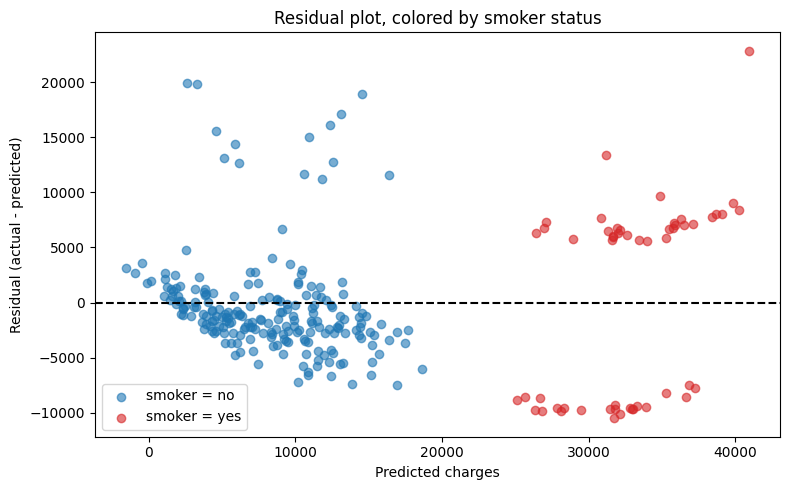

In [8]:
import matplotlib.pyplot as plt

# 1. Residual = actual - predicted (positive = model UNDER-predicted)
residuals = y_test - y_pred

# 2. Recover the smoker label for each TEST row, aligned by index
#    df kept its index; X_test.index tells us which original rows are in the test set
smoker_test = df.loc[X_test.index, 'smoker']   # 'yes' / 'no' per test point

# 3. Scatter residuals vs predicted, colored by smoker status
plt.figure(figsize=(8, 5))
for label, color in [('no', 'tab:blue'), ('yes', 'tab:red')]:
    mask = (smoker_test == label)              # boolean mask: which points are this group
    plt.scatter(y_pred[mask], residuals[mask],
                alpha=0.6, label=f'smoker = {label}', color=color)

plt.axhline(0, color='black', linestyle='--')  # zero line = a perfect prediction
plt.xlabel('Predicted charges')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot, colored by smoker status')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
df2 = df.copy()

df2['smoker_bin'] = (df2['smoker'] == 'yes').astype(int)


df2['bmi_smoker'] = df2['bmi']*df2['smoker_bin']

df2['obese'] = (df2['bmi'] >=30).astype(int)
df2['obese_smoker'] = df2['obese']*df2['smoker_bin']

df2['age2'] = df2['age']**2

y = df2['charges']
X = pd.get_dummies(df2.drop(columns=['charges']),columns=['sex','smoker','region'], drop_first=True)

print(X.head())


   age     bmi  children  smoker_bin  bmi_smoker  obese  obese_smoker  age2  \
0   19  27.900         0           1        27.9      0             0   361   
1   18  33.770         1           0         0.0      1             0   324   
2   28  33.000         3           0         0.0      1             0   784   
3   33  22.705         0           0         0.0      0             0  1089   
4   32  28.880         0           0         0.0      0             0  1024   

   sex_male  smoker_yes  region_northwest  region_southeast  region_southwest  
0     False        True             False             False              True  
1      True       False             False              True             False  
2      True       False             False              True             False  
3      True       False              True             False             False  
4      True       False              True             False             False  


In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)


y_pred = model.predict(X_test)

import numpy as np

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:,.2f}")    
print(f"MAE : {mae:,.2f}")
print(f"R^2 : {r2:.3f}")    

RMSE: 4,261.67
MAE : 2,315.52
R^2 : 0.883


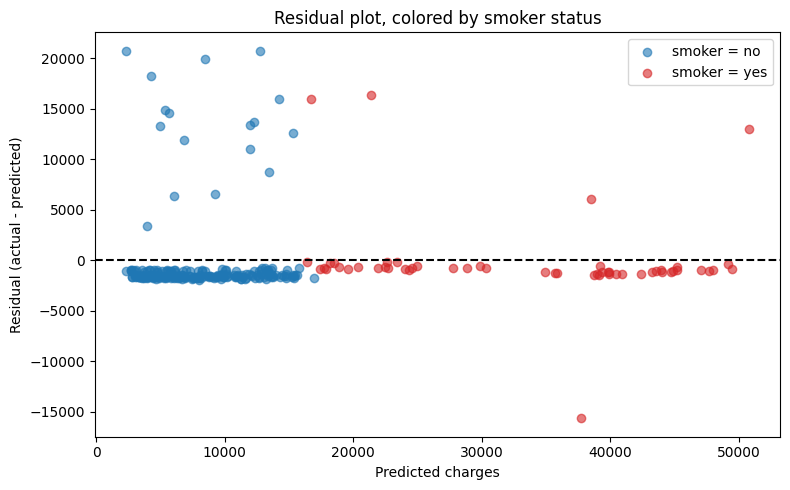

In [14]:
residuals = y_test - y_pred

# 2. Recover the smoker label for each TEST row, aligned by index
#    df kept its index; X_test.index tells us which original rows are in the test set
smoker_test = df.loc[X_test.index, 'smoker']   # 'yes' / 'no' per test point

# 3. Scatter residuals vs predicted, colored by smoker status
plt.figure(figsize=(8, 5))
for label, color in [('no', 'tab:blue'), ('yes', 'tab:red')]:
    mask = (smoker_test == label)              # boolean mask: which points are this group
    plt.scatter(y_pred[mask], residuals[mask],
                alpha=0.6, label=f'smoker = {label}', color=color)

plt.axhline(0, color='black', linestyle='--')  # zero line = a perfect prediction
plt.xlabel('Predicted charges')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot, colored by smoker status')
plt.legend()
plt.tight_layout()
plt.show()